# Reprojection

This notebook investigate how to reproject and combine the categorical rasters from the WorldCover dataset to match the composite image we created for the area of interest.

In [1]:
%load_ext autoreload
%autoreload 2

In [48]:
import os
import pathlib
import sys

sys.path.append(os.path.abspath(".."))

import rioxarray as rxr
from rioxarray.merge import merge_arrays
from rasterio.enums import Resampling
import numpy as np
import xarray as xr
from sklearn.metrics import confusion_matrix

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from src.io import WORLDCOVER_RAW_DIR, MULTISEASONAL_SCENE_DIR
from src.data.sentinel2 import get_data_profile

Get the file paths of two `.tif` images associated with the WorldCover dataset:

In [3]:
files = list(WORLDCOVER_RAW_DIR.glob("*.tif"))[:2]

In [4]:
list(files)

[PosixPath('/Users/stepit/Repositories/projects/lu-lc-classification-with-unet/data/labels/worldcover_raw/ESA_WorldCover_10m_2021_v200_N36W009_Map.tif'),
 PosixPath('/Users/stepit/Repositories/projects/lu-lc-classification-with-unet/data/labels/worldcover_raw/ESA_WorldCover_10m_2021_v200_N36W006_Map.tif')]

Now we get the profile information from the composite image we will use as the feture raster:

In [5]:
profile = get_data_profile(str(MULTISEASONAL_SCENE_DIR/"composite.tif"))
profile

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 5120, 'height': 5120, 'count': 52, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32630"]]'), 'transform': Affine(10.0, 0.0, 200780.0,
       0.0, -10.0, 4151040.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}

In [6]:
file_N36W009 = rxr.open_rasterio(files[0])
file_N36W009

<xarray.DataArray (band: 1, y: 36000, x: 36000)> Size: 1GB
[1296000000 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 288kB 39.0 39.0 39.0 39.0 ... 36.0 36.0 36.0 36.0
  * x            (x) float64 288kB -9.0 -9.0 -9.0 -9.0 ... -6.0 -6.0 -6.0 -6.0
    spatial_ref  int64 8B 0
Attributes: (12/18)
    algorithm_version:  V2.0.0
    copyright:          ESA WorldCover project 2021 / Contains modified Coper...
    creation_time:      2022-10-21 07:35:40.236136
    legend:             10  Tree cover\n20  Shrubland\n30  Grassland\n40  Cro...
    license:            CC-BY 4.0 - https://creativecommons.org/licenses/by/4.0/
    product_crs:        EPSG:4326
    ...                 ...
    time_start:         2021-01-01T00:00:00Z
    title:              ESA WorldCover product at 10m resolution for year 2021
    AREA_OR_POINT:      Area
    _FillValue:         0
    scale_factor:       1.0
    add_offset:         0.0

In [7]:
type(file_N36W009.variable._data), file_N36W009.chunks

(xarray.core.indexing.MemoryCachedArray, None)

This means that the array is not loaded yet, but will be loaded at the first access. Since the size of the array is pretty big, we can prefer to downsample it before visualizing the data. The resampling method we will use is nearest neighborhood because the data is categorical:

In [8]:
factor = 1 / 5
new_width = int(file_N36W009.rio.width * factor)
new_height = int(file_N36W009.rio.height * factor)

file_N36W009_downsampled = file_N36W009.rio.reproject(
    file_N36W009.rio.crs,
    shape=(new_height, new_width),
    resampling=Resampling.nearest,
)

In [9]:
file_N36W009_downsampled

<xarray.DataArray (band: 1, y: 7200, x: 7200)> Size: 52MB
array([[[30, 30, 30, ..., 40, 40, 40],
        [30, 30, 30, ..., 40, 40, 30],
        [30, 30, 30, ..., 30, 30, 30],
        ...,
        [ 0,  0,  0, ..., 80, 80, 80],
        [ 0,  0,  0, ..., 80, 80, 80],
        [ 0,  0,  0, ..., 80, 80, 80]]],
      shape=(1, 7200, 7200), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 58kB 39.0 39.0 39.0 39.0 ... 36.0 36.0 36.0 36.0
  * x            (x) float64 58kB -9.0 -8.999 -8.999 ... -6.001 -6.001 -6.0
    spatial_ref  int64 8B 0
Attributes: (12/18)
    algorithm_version:  V2.0.0
    copyright:          ESA WorldCover project 2021 / Contains modified Coper...
    creation_time:      2022-10-21 07:35:40.236136
    legend:             10  Tree cover\n20  Shrubland\n30  Grassland\n40  Cro...
    license:            CC-BY 4.0 - https://creativecommons.org/licenses/by/4.0/
    product_crs:        EPSG:4326
    ...                 ...
    time_start:         2021-01-01T00:00:00Z
    title:              ESA WorldCover product at 10m resolution for year 2021
    AREA_OR_POINT:      Area
    scale_factor:       1.0
    add_offset:         0.0
    _FillValue:         0

We can verify we still have only the values used by the WorldCover dataset:

In [10]:
np.unique(file_N36W009_downsampled)

array([ 0, 10, 20, 30, 40, 50, 60, 80, 90], dtype=uint8)

We can also load the dask-backed xarray:

In [11]:
file_N36W006 = rxr.open_rasterio(files[1], chunks=True, lock=False)

In [12]:
type(file_N36W006.variable._data), file_N36W006.chunks

(dask.array.core.Array,
 ((1,), (11264, 11264, 11264, 2208), (11264, 11264, 11264, 2208)))

## Reproject on composite

We can now investigate how to reproject the WorldCover categorical tiles on the specific area of interest we care about defined by the multi seasonal composite raster:

In [13]:
composite = rxr.open_rasterio(MULTISEASONAL_SCENE_DIR / "composite.tif", chunks=True, lock=False)

In [14]:
composite.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32630"]]')

In [15]:
composite.rio.bounds(), print(composite.rio.crs)

EPSG:32630


((200780.0, 4099840.0, 251980.0, 4151040.0), None)

In [16]:
file_N36W009.rio.bounds()

(-9.0, 36.0, -6.000000000000001, 39.0)

In [17]:
file_N36W009_reprojected = file_N36W009.rio.reproject_match(composite)

In [18]:
file_N36W009_reprojected.rio.bounds()

(200780.0, 4099840.0, 251980.0, 4151040.0)

Notice that the WorldCover tile was not covering the entire tile, but despite that, the reprojected array is now covering the full tile.

In [19]:
file_N36W006_reprojected = file_N36W006.rio.reproject_match(composite)

In [20]:
file_N36W006_reprojected.rio.bounds()

(200780.0, 4099840.0, 251980.0, 4151040.0)

We can finally combine the two reprojected raster into a single raster:

In [21]:
wc = xr.where(file_N36W009_reprojected != 0, file_N36W009_reprojected, file_N36W006_reprojected)

In [22]:
wc

<xarray.DataArray (band: 1, y: 5120, x: 5120)> Size: 26MB
array([[[40, 40, 40, ..., 10, 10, 10],
        [40, 40, 40, ..., 10, 10, 10],
        [40, 40, 40, ..., 10, 10, 30],
        ...,
        [30, 40, 40, ..., 40, 40, 40],
        [30, 40, 90, ..., 40, 40, 40],
        [30, 40, 90, ..., 40, 40, 40]]],
      shape=(1, 5120, 5120), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 41kB 4.151e+06 4.151e+06 ... 4.1e+06 4.1e+06
  * x            (x) float64 41kB 2.008e+05 2.008e+05 ... 2.52e+05 2.52e+05
    spatial_ref  int64 8B 0
Attributes: (12/18)
    algorithm_version:  V2.0.0
    copyright:          ESA WorldCover project 2021 / Contains modified Coper...
    creation_time:      2022-10-21 07:35:40.236136
    legend:             10  Tree cover\n20  Shrubland\n30  Grassland\n40  Cro...
    license:            CC-BY 4.0 - https://creativecommons.org/licenses/by/4.0/
    product_crs:        EPSG:4326
    ...                 ...
    time_start:         2021-01-01T00:00:00Z
    title:              ESA WorldCover product at 10m resolution for year 2021
    AREA_OR_POINT:      Area
    scale_factor:       1.0
    add_offset:         0.0
    _FillValue:         0

We didn't use the `merge_array` function from `rioxarray` because the two raster were defined over the same bounding box.

## Clip box

We can also adopt the first clip and then reproject approach. This way, we will be able to merge the WorldCover tiles, making the process easier if there are more than 2 rasters, since using the `where` method would not be that easy in this case.

In [23]:
file_N36W006_clipped = file_N36W006.rio.reproject(composite.rio.crs).rio.clip_box(*composite.rio.bounds())

In [24]:
file_N36W006_clipped.rio.bounds()

(229578.62998964224,
 4099837.0488632116,
 251982.55778238596,
 4151040.0554790907)

In [25]:
file_N36W009_clipped = file_N36W009.rio.reproject(composite.rio.crs).rio.clip_box(*composite.rio.bounds())

The merge order is important like for the `where` method.

In [68]:
wc_merged = merge_arrays([file_N36W009_clipped, file_N36W006_clipped])

In [69]:
wc_merged = wc_merged.rio.reproject_match(composite)

In [70]:
wc_merged

<xarray.DataArray (band: 1, y: 5120, x: 5120)> Size: 26MB
array([[[40, 40, 40, ..., 10, 10,  0],
        [40, 40, 40, ..., 10, 10,  0],
        [40, 40, 40, ..., 10, 10,  0],
        ...,
        [30, 40, 40, ..., 40, 40,  0],
        [30, 40, 90, ..., 40, 40,  0],
        [30, 90, 90, ..., 40, 40,  0]]],
      shape=(1, 5120, 5120), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 41kB 4.151e+06 4.151e+06 ... 4.1e+06 4.1e+06
  * x            (x) float64 41kB 2.008e+05 2.008e+05 ... 2.52e+05 2.52e+05
    spatial_ref  int64 8B 0
Attributes: (12/18)
    algorithm_version:  V2.0.0
    copyright:          ESA WorldCover project 2021 / Contains modified Coper...
    creation_time:      2022-10-21 07:35:40.236136
    legend:             10  Tree cover\n20  Shrubland\n30  Grassland\n40  Cro...
    license:            CC-BY 4.0 - https://creativecommons.org/licenses/by/4.0/
    product_crs:        EPSG:4326
    ...                 ...
    time_start:         2021-01-01T00:00:00Z
    title:              ESA WorldCover product at 10m resolution for year 2021
    AREA_OR_POINT:      Area
    scale_factor:       1.0
    add_offset:         0.0
    _FillValue:         0

In [42]:
np.sum(wc_merged != wc).values, np.sum(wc_merged == wc).values, wc_merged.size == wc.size

(array(1195509), array(25018891), True)

In [43]:
np.sum(wc_merged != wc).values / wc_merged.size * 100

np.float64(4.560504913330078)

The issue with this strategy is that we resampled twice, once for the `reproject` and once for the `reproject_match`. A better strategy is:

In [66]:
wc_merged_2 = merge_arrays([file_N36W009, file_N36W006])
wc_merged_2 = wc_merged_2.rio.reproject_match(composite)

In [67]:
np.sum(wc_merged_2 != wc).values / wc_merged_2.size * 100

np.float64(0.0001373291015625)

### Classes confusion

Let's see the confusion matrix between the two approaches to evaluate their consistency.

In [52]:
WORLDCOVER_CLASSES = {
    0: ("No Data", (255, 255, 255)),
    1: ("Tree cover", (0,100,0)),
    2: ("Shrubland", (255, 187, 34)),
    3: ("Grassland", (255, 255, 76)),
    4: ("Cropland", (240, 150, 255)),
    5: ("Build-up", (250, 0, 0)),
    6: ("Bare/sparse vegetation", (180, 180, 180)),
    7: ("Snow and ice", (240, 240, 240)),
    8: ("Permanent water bodies", (0, 100, 200)),
    9: ("Herbaceous wetland", (0, 150, 160)),
    10: ("Mangroves", (0, 207, 117)),
    11: ("Moss and lichen", (250, 230, 160)),
}

In [51]:
wc_1 = wc_reclassed.values.ravel()
wc_2 = wc_merged_reclassed.values.ravel()

In [56]:
present_classes = sorted(np.unique(np.concatenate([wc_1, wc_2])).tolist())
labels = [WORLDCOVER_CLASSES[i][0] for i in present_classes]

In [57]:
cm = confusion_matrix(wc_1, wc_2, labels=present_classes)

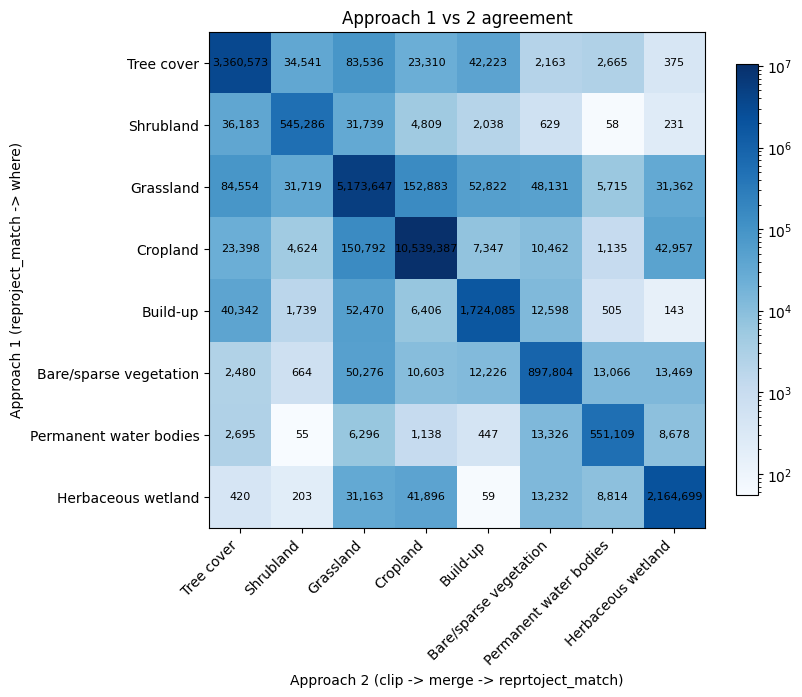

In [60]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues", norm="log")

ax.set_xticks(range(len(present_classes)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(present_classes)), labels)
ax.set_xlabel("Approach 2 (clip -> merge -> reprtoject_match)")
ax.set_ylabel("Approach 1 (reproject_match -> where)")
ax.set_title("Approach 1 vs 2 agreement")

for i in range(len(present_classes)):
    for j in range(len(present_classes)):
        if cm[i, j]:
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=8, color="black")
fig.colorbar(im, ax=ax, shrink=0.8)

So, given the percentage we computed before, the sum on the diagonal accounts for $95\%$ of the pixels, while on the off-diagonal, we have the $5\%$. Since the disagreement should come from the nearest neighbor approach, we should have high values in the off-diagonal for spatially adjacent pairs.

The values could be more informative by reporting the percentage of each class but I'm lazy...

We can also display the disagreement map:

In [71]:
disagree = (wc != wc_merged).squeeze()

In [72]:
disagree.sum()

<xarray.DataArray ()> Size: 8B
array(1195509)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes: (12/18)
    algorithm_version:  V2.0.0
    copyright:          ESA WorldCover project 2021 / Contains modified Coper...
    creation_time:      2022-10-21 07:35:40.236136
    legend:             10  Tree cover\n20  Shrubland\n30  Grassland\n40  Cro...
    license:            CC-BY 4.0 - https://creativecommons.org/licenses/by/4.0/
    product_crs:        EPSG:4326
    ...                 ...
    time_start:         2021-01-01T00:00:00Z
    title:              ESA WorldCover product at 10m resolution for year 2021
    AREA_OR_POINT:      Area
    scale_factor:       1.0
    add_offset:         0.0
    _FillValue:         0

(np.float64(-0.5), np.float64(5119.5), np.float64(5119.5), np.float64(-0.5))

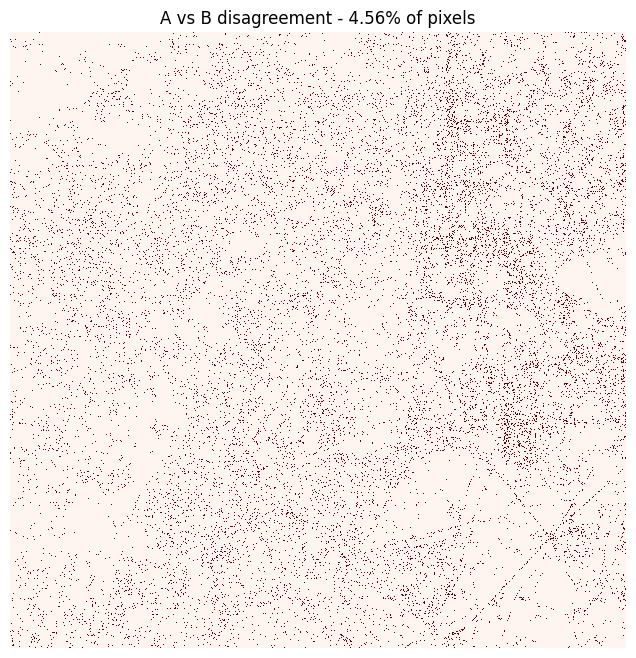

In [74]:
fig, ax, = plt.subplots(figsize=(8, 8))
ax.imshow(disagree, cmap="Reds", interpolation="nearest")
ax.set_title(f"A vs B disagreement - {float(disagree.mean()) * 100:.2f}% of pixels")
ax.axis("off")

## Visualization

We will now visualize the WorldCover dataset covering our AOI by using the same colors used in their website:

In [53]:
def normalize_rgb(rgb):
    return tuple([x / 255 for x in rgb])

In [33]:
n = len(WORLDCOVER_CLASSES.items())
colors = [normalize_rgb(WORLDCOVER_CLASSES.get(i, ("", (0, 0, 0)))[1]) for i in range(n)]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=range(n + 1), ncolors=n)
patches = [
    mpatches.Patch(color=normalize_rgb(color), label=f"{_label}") for (_label, color) in WORLDCOVER_CLASSES.values()
]

In [34]:
CLASS_MAPPING = { 0: 0, 10: 1, 20: 2, 30: 3, 40: 4, 50: 5, 60: 6, 70: 7, 80: 8, 90: 9, 95: 10, 100: 11 }

We first need to change the classes used by WorldCover into sequential class numbers starting from 0 to 11:

In [35]:
wc_reclassed = xr.zeros_like(wc)
for k, v in CLASS_MAPPING.items():
    wc_reclassed = xr.where(wc == k, v, wc_reclassed)

wc_merged_reclassed = xr.zeros_like(wc_merged)
for k, v in CLASS_MAPPING.items():
    wc_merged_reclassed = xr.where(wc_merged == k, v, wc_merged_reclassed)

In [36]:
np.unique(wc_reclassed), len(np.unique(wc_reclassed))

(array([1, 2, 3, 4, 5, 6, 8, 9], dtype=uint8), 8)

In [37]:
np.unique(wc_merged_reclassed), len(np.unique(wc_merged_reclassed))

(array([1, 2, 3, 4, 5, 6, 8, 9], dtype=uint8), 8)

Our area of interest does not contain all the classes.

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

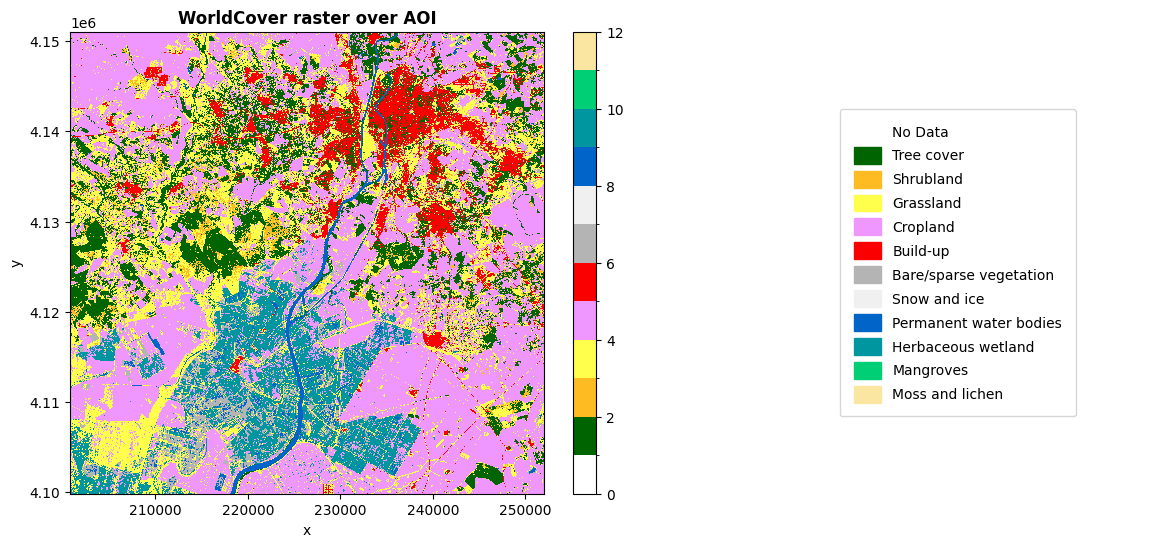

In [79]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 6),  gridspec_kw={"width_ratios": [3, 2]})

wc_reclassed.plot(ax=ax[0], cmap=cmap, norm=norm)
ax[0].set_title("WorldCover raster over AOI", fontweight="bold")

ax[1].legend(
    handles=patches,
    loc="center",
    frameon=True,
    fontsize=10,
    handlelength=2,
    handleheight=1.5,
    borderpad=1,
)
ax[1].axis("off")

In [95]:
_wc = rxr.open_rasterio("../data/labels/worldcover_classes.tif")

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

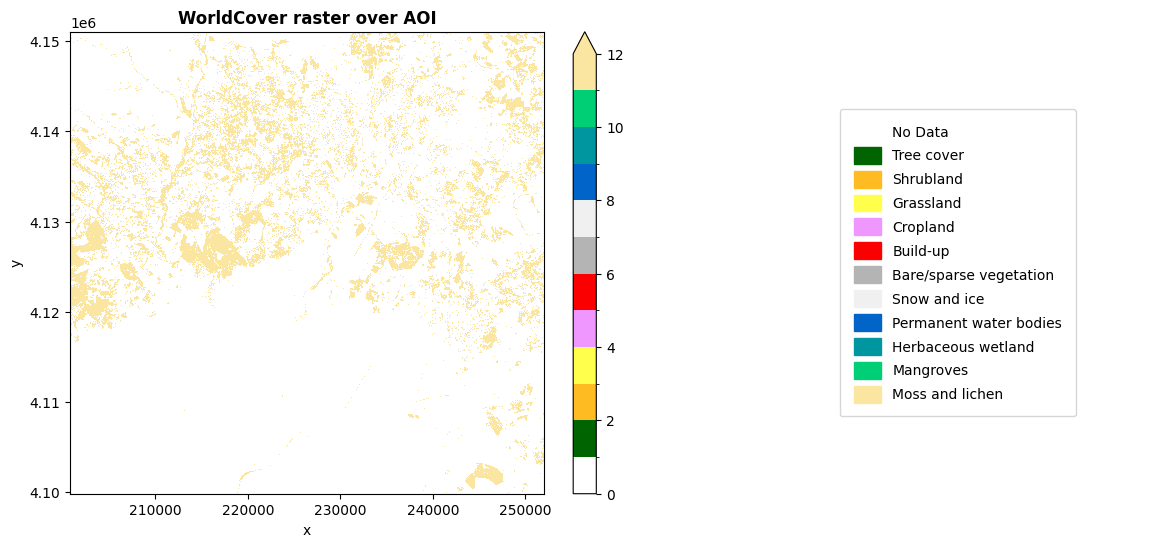

In [94]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 6),  gridspec_kw={"width_ratios": [3, 2]})

_wc.plot(ax=ax[0], cmap=cmap, norm=norm)
ax[0].set_title("WorldCover raster over AOI", fontweight="bold")

ax[1].legend(
    handles=patches,
    loc="center",
    frameon=True,
    fontsize=10,
    handlelength=2,
    handleheight=1.5,
    borderpad=1,
)
ax[1].axis("off")

In [96]:
np.unique(_wc)

array([ 0, 95], dtype=uint8)